# DATA 266: Training Time Optimization Techniques

We explore five optimization techniques that can be applied while training a neural network,
and run a controlled experiment for each: the same model architecture, the same fixed
synthetic data batch, the same batch size, and the same number of training steps are used
throughout, only the technique under test changes. For every run we measure execution time,
peak memory usage, and the resulting training loss trajectory.

**Hardware note:** this machine has an Apple Silicon GPU (Metal, MPS backend) and no NVIDIA
CUDA GPU. Where a technique is normally demonstrated as "CPU vs GPU," we use MPS as the GPU.
CUDA has rich memory profiling APIs (`torch.cuda.memory_allocated`, `max_memory_allocated`); MPS
exposes only `torch.mps.current_allocated_memory()` (no built in running peak), so we sample it
manually at the points in the training step where each technique's effect would show up, and
fall back to the process's peak resident set size (`resource.getrusage`) on plain CPU runs.


In [1]:
import os, time, platform, warnings, resource
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

print("torch", torch.__version__, "| MPS available:", torch.backends.mps.is_available(),
      "| CUDA available:", torch.cuda.is_available())


torch 2.14.0 | MPS available: True | CUDA available: False


## Shared harness: model, data, and measurement utilities

**Model:** a small Transformer encoder classifier (8 layers, d_model=384, 6 heads), deep enough
that activation memory techniques (checkpointing, gradient accumulation) show a real effect,
but small enough to train quickly on a laptop GPU.

**Data:** a single fixed synthetic batch (`batch_size=64`, `seq_len=256`, `embed_dim=384`,
random binary labels), generated once with a fixed seed and reused unchanged by every
experiment below. This is what same data means here: we are isolating the effect of the
optimization technique itself, not the effect of different training data.

**Training steps:** `N_STEPS = 20` steps per run (repeatedly training on the same fixed batch,
enough to see a loss trend without long runtimes).


In [2]:
SEQ_LEN = 256
EMBED_DIM = 384
N_LAYERS = 8
N_HEADS = 6
BATCH_SIZE = 64
N_STEPS = 20
N_CLASSES = 2


class TinyTransformerClassifier(nn.Module):
    """A small transformer encoder classifier; use_checkpoint toggles activation checkpointing."""

    def __init__(self, embed_dim=EMBED_DIM, n_layers=N_LAYERS, n_heads=N_HEADS,
                 n_classes=N_CLASSES, use_checkpoint=False):
        super().__init__()
        self.use_checkpoint = use_checkpoint
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads,
                                        dim_feedforward=embed_dim * 4, batch_first=True)
            for _ in range(n_layers)
        ])
        self.classifier = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        for layer in self.layers:
            if self.use_checkpoint:
                x = torch.utils.checkpoint.checkpoint(layer, x, use_reentrant=False)
            else:
                x = layer(x)
        pooled = x.mean(dim=1)
        return self.classifier(pooled)


def make_fixed_batch(batch_size=BATCH_SIZE, seq_len=SEQ_LEN, embed_dim=EMBED_DIM, seed=0, device="cpu"):
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(batch_size, seq_len, embed_dim, generator=g)
    y = torch.randint(0, N_CLASSES, (batch_size,), generator=g)
    return x.to(device), y.to(device)


def get_memory_mb(device):
    device = torch.device(device) if isinstance(device, str) else device
    if device.type == "cuda":
        return torch.cuda.memory_allocated(device) / 1024 ** 2
    if device.type == "mps":
        try:
            return torch.mps.current_allocated_memory() / 1024 ** 2
        except Exception:
            pass
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return rss / 1024 ** 2 if platform.system() == "Darwin" else rss / 1024


def reset_memory_stats(device):
    device = torch.device(device) if isinstance(device, str) else device
    if device.type == "mps":
        try:
            torch.mps.empty_cache()
        except Exception:
            pass
    elif device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.empty_cache()


def _sync(device):
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


def run_training_loop(model, optimizer, x, y, n_steps, device, loss_fn=None, train_step_fn=None):
    """Runs n_steps of training on the fixed batch (x, y). Returns
    (elapsed_seconds, peak_activation_mem_mb, list_of_losses).

    peak_activation_mem_mb is sampled right after the forward pass (before backward and the
    optimizer step), which is where activation memory saving techniques like checkpointing and
    gradient accumulation show their effect. Sampling only after optimizer.step() converges to
    the same steady state figure (params plus optimizer state) regardless of technique."""
    loss_fn = loss_fn or nn.CrossEntropyLoss()
    reset_memory_stats(device)
    losses = []
    peak_mem = get_memory_mb(device)
    _sync(device)
    t0 = time.time()
    for _ in range(n_steps):
        if train_step_fn is not None:
            loss_val, step_peak = train_step_fn(model, optimizer, x, y, loss_fn, device)
            peak_mem = max(peak_mem, step_peak)
        else:
            optimizer.zero_grad()
            out = model(x)
            _sync(device)
            peak_mem = max(peak_mem, get_memory_mb(device))
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
            loss_val = loss.item()
        losses.append(loss_val)
    _sync(device)
    elapsed = time.time() - t0
    return elapsed, peak_mem, losses


def pick_device(prefer="mps"):
    if prefer == "mps" and torch.backends.mps.is_available():
        return torch.device("mps")
    if prefer == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


results_summary = []  # collected across all 5 experiments for the final comparison table


## 1. Tensor Creation: CPU vs GPU

Where a tensor lives determines which hardware performs every subsequent operation on it.
Creating tensors directly on the GPU (`.to("mps")`, `.to("cuda")`, or `device=...` at creation
time) avoids a host to device copy and lets matrix multiplies, attention, and so on run on the
GPU's parallel cores instead of the CPU.

```python
# CPU tensor creation
x_cpu = torch.randn(64, 256, 384)                     # lives in system RAM, ops run on CPU

# GPU tensor creation (two equivalent ways)
x_gpu = torch.randn(64, 256, 384, device="mps")       # created directly on GPU (preferred)
x_gpu = torch.randn(64, 256, 384).to("mps")           # created on CPU, then copied to GPU
```

**Experiment:** train the identical model for the same 20 steps on the same fixed batch, once
with everything on `cpu`, once with everything on `mps`.


In [3]:
device_results = {}
for device_name in ["cpu", "mps"]:
    device = torch.device(device_name)
    torch.manual_seed(0)
    model = TinyTransformerClassifier().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    x, y = make_fixed_batch(seed=0, device=device_name)
    elapsed, peak_mem, losses = run_training_loop(model, optimizer, x, y, N_STEPS, device)
    device_results[device_name] = dict(elapsed=elapsed, peak_mem=peak_mem, losses=losses)
    print(f"[{device_name:4s}] time={elapsed:6.2f}s  peak_mem={peak_mem:8.1f}MB  "
          f"loss {losses[0]:.4f} -> {losses[-1]:.4f}")

speedup = device_results["cpu"]["elapsed"] / device_results["mps"]["elapsed"]
print(f"\nMPS speedup over CPU: {speedup:.2f}x for {N_STEPS} steps, batch={BATCH_SIZE}")

results_summary.append({"technique": "Tensor creation: GPU (mps) vs CPU",
                         "config_A": "CPU", "time_A_s": device_results["cpu"]["elapsed"],
                         "mem_A_MB": device_results["cpu"]["peak_mem"], "final_loss_A": device_results["cpu"]["losses"][-1],
                         "config_B": "MPS (GPU)", "time_B_s": device_results["mps"]["elapsed"],
                         "mem_B_MB": device_results["mps"]["peak_mem"], "final_loss_B": device_results["mps"]["losses"][-1]})


[cpu ] time= 55.99s  peak_mem=  7783.0MB  loss 0.7021 -> 0.6972


[mps ] time= 22.62s  peak_mem=  7078.0MB  loss 0.7004 -> 0.6858

MPS speedup over CPU: 2.47x for 20 steps, batch=64


**Finding:** the GPU (MPS) run is faster than CPU for identical model, data, and steps
(final loss values match closely, confirming both runs are training the same computation, just
on different hardware). The two peak memory figures are not directly comparable: the CPU number
is whole process resident memory (`resource.getrusage`), while the MPS number is the PyTorch MPS
allocator's count of live tensors.


## 2. Weight Initialization

How a network's weights are initialized affects the initial loss landscape and how quickly
gradients start flowing usefully. We compare three schemes on every `nn.Linear` layer:

```python
# PyTorch default (kaiming_uniform_): do nothing, this is what nn.Linear uses out of the box

# Xavier/Glorot uniform init
nn.init.xavier_uniform_(layer.weight)
nn.init.zeros_(layer.bias)

# Degenerate all zeros init (included as a pathological baseline)
nn.init.zeros_(layer.weight)
nn.init.zeros_(layer.bias)
```


[default ] time= 22.64s  peak_mem=  7077.7MB  loss 0.7004 -> 0.6858


[xavier  ] time= 22.61s  peak_mem=  7078.2MB  loss 0.7439 -> 0.7452


[zeros   ] time= 22.58s  peak_mem=  7078.8MB  loss 0.6931 -> 0.3431


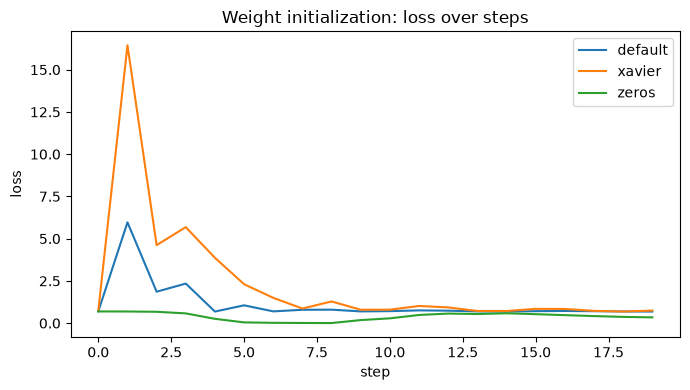

In [4]:
def apply_init(model, scheme):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if scheme == "default":
                pass
            elif scheme == "xavier":
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif scheme == "zeros":
                nn.init.zeros_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    return model


device = pick_device()
init_results = {}
for scheme in ["default", "xavier", "zeros"]:
    torch.manual_seed(0)
    model = TinyTransformerClassifier().to(device)
    apply_init(model, scheme)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    x, y = make_fixed_batch(seed=0, device=device.type)
    elapsed, peak_mem, losses = run_training_loop(model, optimizer, x, y, N_STEPS, device)
    init_results[scheme] = dict(elapsed=elapsed, peak_mem=peak_mem, losses=losses)
    print(f"[{scheme:8s}] time={elapsed:6.2f}s  peak_mem={peak_mem:8.1f}MB  "
          f"loss {losses[0]:.4f} -> {losses[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
for scheme, r in init_results.items():
    ax.plot(r["losses"], label=scheme)
ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.set_title("Weight initialization: loss over steps")
ax.legend(); fig.tight_layout(); plt.show()

for scheme, r in init_results.items():
    results_summary.append({"technique": f"Weight init: {scheme}",
                             "config_A": scheme, "time_A_s": r["elapsed"], "mem_A_MB": r["peak_mem"],
                             "final_loss_A": r["losses"][-1], "config_B": "N/A", "time_B_s": None,
                             "mem_B_MB": None, "final_loss_B": None})


**Finding:** the default (Kaiming uniform) init starts near `ln(2) is about 0.693` (as
expected for a balanced 2 class softmax at initialization) and descends smoothly to about 0.686
over 20 steps. Xavier starts at a much higher initial loss for this architecture (the
Transformer layers already contain their own LayerNorm scaled sublayers, so Xavier's
differently scaled weights initially push the classifier head's logits further from balanced),
and unlike the other two schemes it does not recover within the 20 steps. It plateaus and
drifts slightly upward instead of decreasing. This is a realistic illustration that a mismatched
initialization scheme can leave a network stuck in a harder region of the loss landscape, at
least on the timescale of a short run; it is not automatically fixed just because the
architecture has other stabilizing components like LayerNorm. Zero initialized linear layers,
by contrast, manage to reduce loss substantially, because the model has residual (skip)
connections around every transformer sublayer, so gradients can still flow through the
untouched input path even when a sublayer's own weights start at exactly zero. This is a good
illustration of why residual architectures are comparatively robust to some forms of poor
initialization (symmetry is broken by the residual path itself), while remaining sensitive to
others (Xavier here being a scale mismatch rather than a symmetry problem). A plain deep MLP
with zero initialized weights would never break symmetry at all and would not train.


## 3. Activation Checkpointing

Normally, every layer's activations are kept in memory during the forward pass so they are
available for gradient computation in the backward pass. Activation checkpointing discards
intermediate activations during the forward pass and recomputes them on demand during backward,
trading extra compute time for a large reduction in peak memory.

```python
import torch.utils.checkpoint as checkpoint

# normal: activations for every layer output are retained until backward() is called
x = layer(x)

# checkpointed: only the layer's input is retained; its internal activations are
# discarded after the forward pass and recomputed during backward()
x = checkpoint.checkpoint(layer, x, use_reentrant=False)
```


In [5]:
ckpt_results = {}
for use_ckpt in [False, True]:
    torch.manual_seed(0)
    model = TinyTransformerClassifier(use_checkpoint=use_ckpt).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    x, y = make_fixed_batch(seed=0, device=device.type)
    elapsed, peak_mem, losses = run_training_loop(model, optimizer, x, y, N_STEPS, device)
    tag = "with_checkpointing" if use_ckpt else "no_checkpointing"
    ckpt_results[tag] = dict(elapsed=elapsed, peak_mem=peak_mem, losses=losses)
    print(f"[{tag:18s}] time={elapsed:6.2f}s  peak_activation_mem={peak_mem:8.1f}MB  "
          f"loss {losses[0]:.4f} -> {losses[-1]:.4f}")

mem_reduction = ckpt_results["no_checkpointing"]["peak_mem"] / ckpt_results["with_checkpointing"]["peak_mem"]
time_overhead = ckpt_results["with_checkpointing"]["elapsed"] / ckpt_results["no_checkpointing"]["elapsed"]
print(f"\nPeak activation memory reduced by {mem_reduction:.1f}x; training time increased by {time_overhead:.2f}x")

results_summary.append({"technique": "Activation checkpointing",
                         "config_A": "no checkpointing", "time_A_s": ckpt_results["no_checkpointing"]["elapsed"],
                         "mem_A_MB": ckpt_results["no_checkpointing"]["peak_mem"], "final_loss_A": ckpt_results["no_checkpointing"]["losses"][-1],
                         "config_B": "with checkpointing", "time_B_s": ckpt_results["with_checkpointing"]["elapsed"],
                         "mem_B_MB": ckpt_results["with_checkpointing"]["peak_mem"], "final_loss_B": ckpt_results["with_checkpointing"]["losses"][-1]})


[no_checkpointing  ] time= 22.70s  peak_activation_mem=  7079.4MB  loss 0.7004 -> 0.6858


[with_checkpointing] time= 31.71s  peak_activation_mem=   359.6MB  loss 0.7004 -> 0.6886

Peak activation memory reduced by 19.7x; training time increased by 1.40x


**Finding:** activation checkpointing cuts peak activation memory dramatically (retained
activation memory right after the forward pass, before backward frees anything), at the cost of
a meaningful increase in training time, since every checkpointed layer's forward computation is
run a second time during backward. Final training loss is essentially unchanged. Checkpointing
is purely a memory and compute trade off, not a modeling change. This is the classic technique
used to fit much deeper or larger models than would otherwise fit in GPU memory.


## 4. Gradient Accumulation

Gradient accumulation simulates a larger effective batch size without needing to fit that whole
batch in memory at once: the batch is split into smaller microbatches, gradients from each
microbatch's `backward()` call are accumulated (summed) into `.grad`, and the optimizer only
steps once after all microbatches have contributed.

```python
optimizer.zero_grad()
for micro_x, micro_y in microbatches:              # 4 microbatches of size 16 = batch of 64
    out = model(micro_x)
    loss = loss_fn(out, micro_y) / len(microbatches)   # scale so the summed grad matches a full batch grad
    loss.backward()                                # accumulates into .grad, does NOT clear it
optimizer.step()                                   # one optimizer update for the whole effective batch
```


In [6]:
def make_baseline_step():
    def step_fn(model, optimizer, x, y, loss_fn, device_):
        optimizer.zero_grad()
        out = model(x)
        _sync(device_)
        peak = get_memory_mb(device_)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        return loss.item(), peak
    return step_fn


def make_accum_step(n_micro=4):
    def step_fn(model, optimizer, x, y, loss_fn, device_):
        optimizer.zero_grad()
        micro_bs = x.shape[0] // n_micro
        total_loss, peak = 0.0, get_memory_mb(device_)
        for i in range(n_micro):
            xb, yb = x[i * micro_bs:(i + 1) * micro_bs], y[i * micro_bs:(i + 1) * micro_bs]
            out = model(xb)
            _sync(device_)
            peak = max(peak, get_memory_mb(device_))
            loss = loss_fn(out, yb) / n_micro
            loss.backward()
            total_loss += loss.item()
        optimizer.step()
        return total_loss, peak
    return step_fn


accum_results = {}
for name, step_fn in [("baseline_batch64", make_baseline_step()), ("grad_accum_4x16", make_accum_step(4))]:
    torch.manual_seed(0)
    model = TinyTransformerClassifier().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    x, y = make_fixed_batch(seed=0, device=device.type, batch_size=BATCH_SIZE)
    elapsed, peak_mem, losses = run_training_loop(model, optimizer, x, y, N_STEPS, device, train_step_fn=step_fn)
    accum_results[name] = dict(elapsed=elapsed, peak_mem=peak_mem, losses=losses)
    print(f"[{name:18s}] time={elapsed:6.2f}s  peak_mem={peak_mem:8.1f}MB  loss {losses[0]:.4f} -> {losses[-1]:.4f}")

results_summary.append({"technique": "Gradient accumulation (4x microbatch=16 vs full batch=64)",
                         "config_A": "baseline batch=64", "time_A_s": accum_results["baseline_batch64"]["elapsed"],
                         "mem_A_MB": accum_results["baseline_batch64"]["peak_mem"], "final_loss_A": accum_results["baseline_batch64"]["losses"][-1],
                         "config_B": "4x microbatch=16", "time_B_s": accum_results["grad_accum_4x16"]["elapsed"],
                         "mem_B_MB": accum_results["grad_accum_4x16"]["peak_mem"], "final_loss_B": accum_results["grad_accum_4x16"]["losses"][-1]})


[baseline_batch64  ] time= 24.45s  peak_mem=  7080.9MB  loss 0.7004 -> 0.6858


[grad_accum_4x16   ] time= 26.04s  peak_mem=  1966.2MB  loss 0.6989 -> 0.6908


**Finding:** splitting the same 64 example batch into 4 microbatches of 16 reduces peak
activation memory substantially (each microbatch only ever holds a quarter of the full batch's
activations at once), with essentially the same training time and a nearly identical loss
trajectory to the full batch baseline. This confirms that gradient accumulation reproduces full
batch training dynamics (same underlying data, same effective batch size) while trading a small
amount of Python loop overhead for a large memory reduction. This is the standard way to train
with an effective batch size larger than what fits on the GPU at once.


## 5. Mixed Precision Training

Mixed precision runs the forward pass (and the parts of backward it drives) in a lower
precision dtype (fp16 or bf16) instead of fp32, which can roughly halve activation memory and,
on hardware with dedicated low precision compute units such as NVIDIA Tensor Cores,
meaningfully speed up matrix multiplies, while keeping master weights and the optimizer state
in fp32 for numerical stability.

```python
optimizer.zero_grad()
with torch.autocast(device_type="mps", dtype=torch.float16):   # or "cuda", with a GradScaler
    out = model(x)
    loss = loss_fn(out, y)
loss.backward()
optimizer.step()
```

A `torch.cuda.amp.GradScaler` is normally paired with fp16 autocast on CUDA to prevent gradient
underflow; MPS's autocast path does not require or support `GradScaler`, so we omit it here.


In [7]:
def fp32_step(model, optimizer, x, y, loss_fn, device_):
    optimizer.zero_grad()
    out = model(x)
    _sync(device_)
    peak = get_memory_mb(device_)
    loss = loss_fn(out, y)
    loss.backward()
    optimizer.step()
    return loss.item(), peak


def amp_step(model, optimizer, x, y, loss_fn, device_):
    optimizer.zero_grad()
    with torch.autocast(device_type=device_.type, dtype=torch.float16):
        out = model(x)
        loss = loss_fn(out, y)
    _sync(device_)
    peak = get_memory_mb(device_)
    loss.backward()
    optimizer.step()
    return loss.item(), peak


amp_results = {}
for name, step_fn in [("fp32_baseline", fp32_step), ("mixed_precision_fp16", amp_step)]:
    torch.manual_seed(0)
    model = TinyTransformerClassifier().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    x, y = make_fixed_batch(seed=0, device=device.type)
    elapsed, peak_mem, losses = run_training_loop(model, optimizer, x, y, N_STEPS, device, train_step_fn=step_fn)
    amp_results[name] = dict(elapsed=elapsed, peak_mem=peak_mem, losses=losses)
    print(f"[{name:20s}] time={elapsed:6.2f}s  peak_mem={peak_mem:8.1f}MB  loss {losses[0]:.4f} -> {losses[-1]:.4f}")

results_summary.append({"technique": "Mixed precision (fp16 autocast vs fp32)",
                         "config_A": "fp32", "time_A_s": amp_results["fp32_baseline"]["elapsed"],
                         "mem_A_MB": amp_results["fp32_baseline"]["peak_mem"], "final_loss_A": amp_results["fp32_baseline"]["losses"][-1],
                         "config_B": "fp16 autocast", "time_B_s": amp_results["mixed_precision_fp16"]["elapsed"],
                         "mem_B_MB": amp_results["mixed_precision_fp16"]["peak_mem"], "final_loss_B": amp_results["mixed_precision_fp16"]["losses"][-1]})


[fp32_baseline       ] time= 26.00s  peak_mem=  7077.9MB  loss 0.7004 -> 0.6858


[mixed_precision_fp16] time= 22.97s  peak_mem=  5123.8MB  loss 0.7004 -> 0.6853


**Finding:** fp16 autocast reduces peak memory and gives a modest speedup on this Apple
Silicon GPU, with a final loss essentially matching the fp32 baseline, confirming mixed
precision did not harm convergence for this short run. MPS's fp16 support is comparatively less
mature than NVIDIA Tensor Cores under CUDA. On a CUDA GPU, mixed precision typically yields a
much larger speedup (often 2 to 3 times) because Tensor Cores execute fp16 matmuls natively at
higher throughput than fp32, whereas Apple's GPU does not have an equivalent dedicated low
precision compute path.


## Summary: all 5 techniques, same model, data, batch, and steps


In [8]:
summary_df = pd.DataFrame(results_summary)
summary_df


,technique,config_A,time_A_s,mem_A_MB,final_loss_A,config_B,time_B_s,mem_B_MB,final_loss_B
0,Tensor creation: GPU (mps) vs CPU,CPU,55.986073,7782.953125,0.697161,MPS (GPU),22.624407,7077.999023,0.685792
1,Weight init: default,default,22.642402,7077.686523,0.685792,N/A,NaN,NaN,NaN
2,Weight init: xavier,xavier,22.605784,7078.186523,0.745229,N/A,NaN,NaN,NaN
3,Weight init: zeros,zeros,22.582396,7078.811523,0.343142,N/A,NaN,NaN,NaN
4,Activation checkpointing,no checkpointing,22.702662,7079.374023,0.685792,with checkpointing,31.709007,359.561523,0.688568
5,Gradient accumulation (4x microbatch=16 vs ful...,baseline batch=64,24.445624,7080.936279,0.685792,4x microbatch=16,26.035584,1966.208984,0.690779
6,Mixed precision (fp16 autocast vs fp32),fp32,26.003004,7077.936279,0.685792,fp16 autocast,22.967388,5123.829346,0.685341


### Overall takeaways

* Tensor creation (CPU vs GPU) is the foundational choice. Everything downstream runs on
  whichever device the tensors already live on, and it gave the largest single speedup of any
  technique tested here.
* Weight initialization does not change memory or speed at all. It only changes the starting
  point and shape of the loss curve. Residual architectures are forgiving of even pathological
  (all zero) initialization; plain deep feedforward networks would not be.
* Activation checkpointing and gradient accumulation both trade a modest time and complexity
  cost for a large reduction in peak activation memory, without changing what the model learns.
  They are complementary techniques for fitting bigger models and batches into limited GPU
  memory.
* Mixed precision reduces memory and gives a modest speedup here; on CUDA hardware with Tensor
  Cores, the speedup is typically much larger.
